# Entrenamiento, validacion y testeo

In [214]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from formulaic import Formula

## Ejercicio 1

In [2]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
penguins.isnull().values.any() # isnull es un alias de isna

np.True_

In [4]:
penguins.isnull().values.sum() # esto me dice cuantos null hay

np.int64(19)

In [5]:
penguins.info() # Para ver cuantos nan hay por columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
penguins.dropna(inplace=True) # Tiro filas que contienen nan

In [7]:
penguins.isnull().values.any()

np.False_

In [8]:
# Separo en train y test, 80-20
X = penguins["flipper_length_mm"]
y = penguins["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

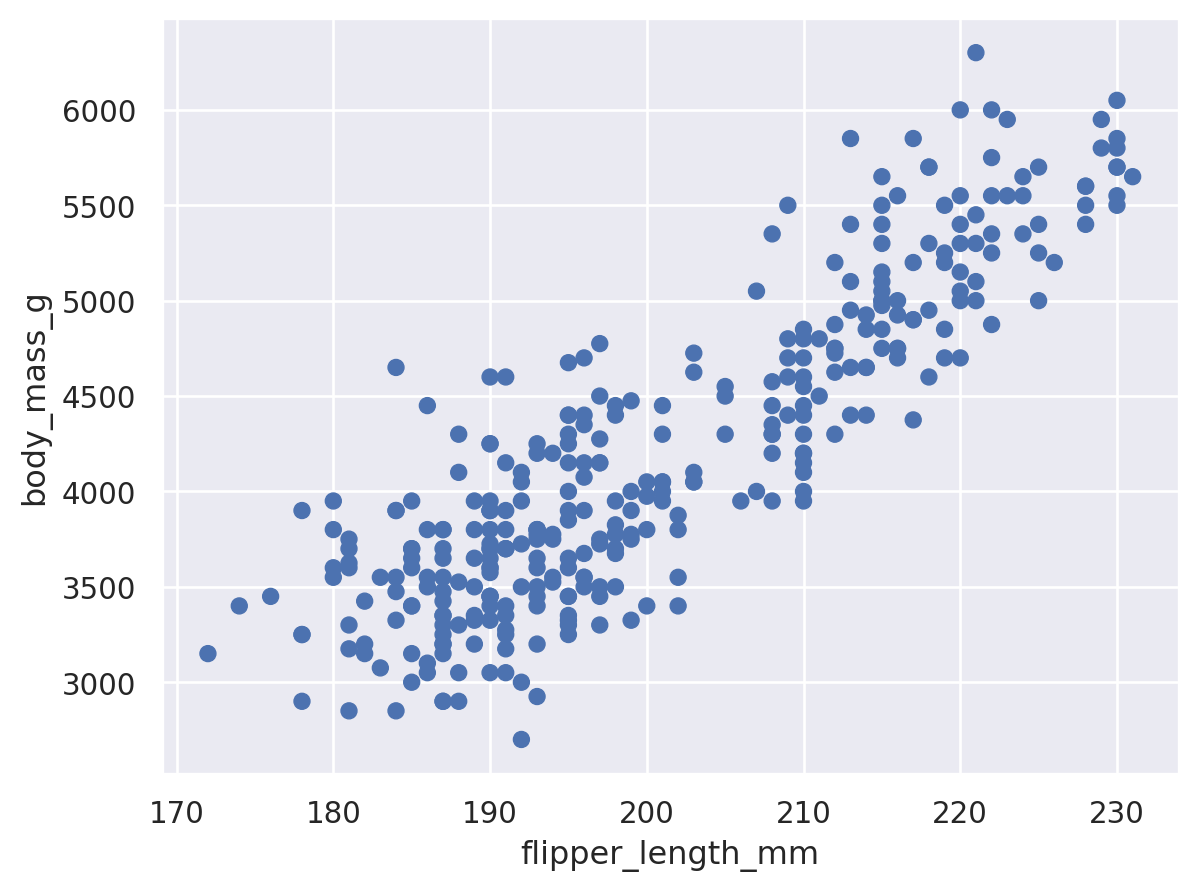

In [9]:
(
    so.Plot(penguins, x="flipper_length_mm", y="body_mass_g")
    .add(so.Dot())
)

In [10]:
# Uso PolynomialFeatures

In [11]:
# Grado 1
X = penguins[["flipper_length_mm"]]
poly = PolynomialFeatures(1)
X = poly.fit_transform(X)
y = penguins["body_mass_g"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = linear_model.LinearRegression(fit_intercept=True)
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Error cuadratico medio
ECM_train = mean_squared_error(y_train, y_pred_train)
ECM_test = mean_squared_error(y_test, y_pred_test)

print(f"ECM train: {ECM_train}\nECM test: {ECM_test}")
print(f"Coeficientes: {modelo.coef_}")

ECM train: 159873.09549908538
ECM test: 129886.71972544755
Coeficientes: [ 0.         50.41798199]


In [12]:
# Grado 2
X = penguins[["flipper_length_mm"]]
poly = PolynomialFeatures(2)
X = poly.fit_transform(X)
y = penguins["body_mass_g"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = linear_model.LinearRegression(fit_intercept=True)
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Error cuadratico medio
ECM_train = mean_squared_error(y_train, y_pred_train)
ECM_test = mean_squared_error(y_test, y_pred_test)

print(f"ECM train: {ECM_train}\nECM test: {ECM_test}")
print(f"Coeficientes: {modelo.coef_}")

ECM train: 147737.6311072206
ECM test: 127731.22567377472
Coeficientes: [   0.         -193.49746518    0.60030709]


In [13]:
# Grado 3
X = penguins[["flipper_length_mm"]]
poly = PolynomialFeatures(3)
X = poly.fit_transform(X)
y = penguins["body_mass_g"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = linear_model.LinearRegression(fit_intercept=True)
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Error cuadratico medio
ECM_train = mean_squared_error(y_train, y_pred_train)
ECM_test = mean_squared_error(y_test, y_pred_test)

print(f"ECM train: {ECM_train}\nECM test: {ECM_test}")
print(f"Coeficientes: {modelo.coef_}")

ECM train: 143995.99465654884
ECM test: 123664.64922893427
Coeficientes: [ 0.00000000e+00 -2.60703406e+03  1.25325842e+01 -1.96046866e-02]


De los tres modelos:

- el que tiene menor error en el ajuste (train) es el de grado 3
- el que tiene menor error en la prediccion (test) es el de grado 3

Sin embargo, el error en la prediccion no baja tanto, asi que probablemente alcance con usar el de grado 1 o 2

## Ejercicio 2

In [14]:
startups = pd.read_csv("../Notebooks/Datasets-20260209/50_Startups.csv")
startups.head()

,Investigacion,Administracion,Marketing,Estado,Ganancia
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [15]:
startups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Investigacion   50 non-null     float64
 1   Administracion  50 non-null     float64
 2   Marketing       50 non-null     float64
 3   Estado          50 non-null     object 
 4   Ganancia        50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


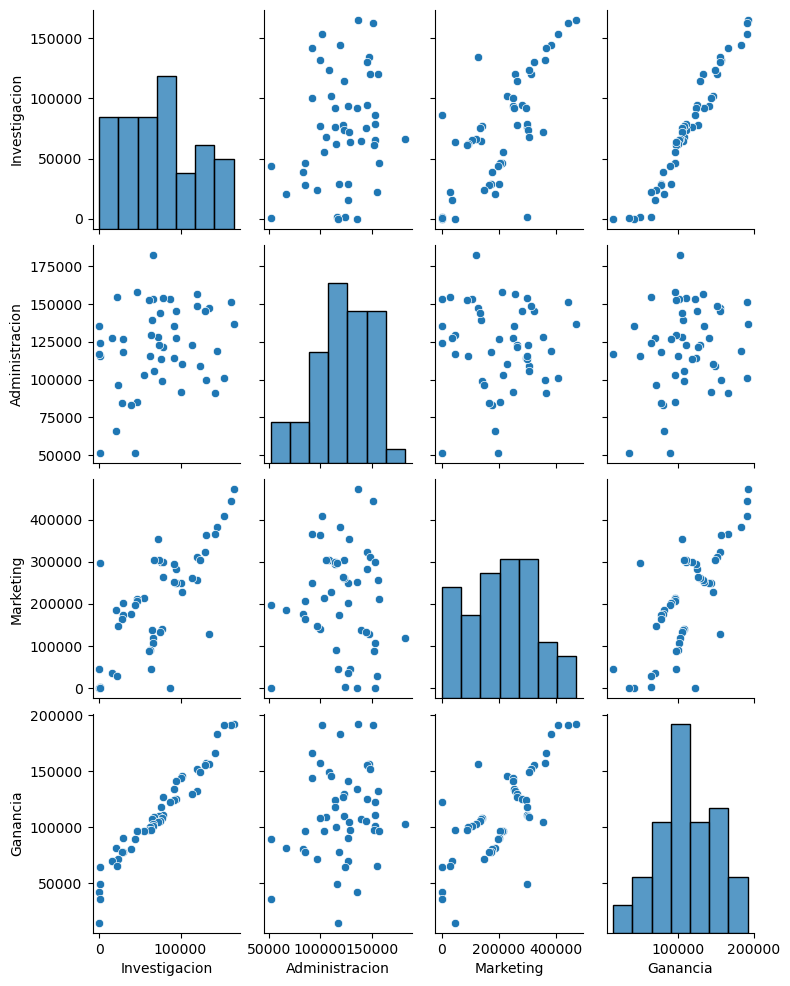

In [16]:
sns.pairplot(data=startups, aspect=.8)

Si hubiera que elegir una sola variable predictora para predecir Ganancia, seria **Investigacion**, 

ya que segun los graficos el que mas relacion lineal presenta es el de Ganancia vs Investigacion

Podria realizar un ajuste lineal entre Ganancia y cada una de las otras variables, y ver cual tiene mayor R2

In [17]:
ganancia = startups["Ganancia"]
investigacion = startups[["Investigacion"]]
administracion = startups[["Administracion"]]
marketing = startups[["Marketing"]]

In [18]:
def ganancia_vs_cols(
    data: pd.DataFrame,
    respuesta: str,
    columnas: list[str]
) -> float:
    y = data[respuesta]
    X = data[columnas]
    
    #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.05, random_state = 42)

    modelo = linear_model.LinearRegression()
    modelo.fit(X, y)

    y_pred = modelo.predict(X)

    return r2_score(y, y_pred)

In [20]:
r2_inv = ganancia_vs_cols(startups, "Ganancia", ["Investigacion"])
r2_adm = ganancia_vs_cols(startups, "Ganancia", ["Administracion"])
r2_mkt = ganancia_vs_cols(startups, "Ganancia", ["Marketing"])

In [21]:
print(f"r2 investigacion: {r2_inv}")
print(f"r2 administracion: {r2_adm}")
print(f"r2 marketing: {r2_mkt}")

r2 investigacion: 0.9465353160804393
r2 administracion: 0.04028714077757223
r2 marketing: 0.5591535746115515


Viendo el r2 de cada variable contra ganancia, vemos que el mas alto es **Investigacion**, como se esperaba

Probablemente un modelo lineal multivariado podria ayudar a predecir mejor la ganancia, incluyendo investigacion y marketing

In [22]:
ganancia_vs_cols(startups, "Ganancia", ["Investigacion", "Marketing"])

0.9504503015559763

## Ejercicio 3

In [23]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [24]:
penguins["sex"].value_counts()

sex
Male      168
Female    165
Name: count, dtype: int64

La variable *sex* es de tipo string, toma valores **Male** y **Female**.

Es un tipo de variable *categorica nomimal*. Podemos considerarla como *binaria*, ya que tiene dos valores posibles.

Modelo lineal. La variable sex puede codificarse como sex_male (1 si es Male, 0 si es Female por ejemplo)

$$ body\_mass\_g = \beta_0 + \beta_1 * flipper\_length\_mm + \beta_2 * sex\_male $$

In [35]:
y, X = (
    Formula("body_mass_g ~ flipper_length_mm + sex")
    .get_model_matrix(penguins)
)

In [36]:
X.head()

,Intercept,flipper_length_mm,sex[T.Male]
0,1.0,181.0,1
1,1.0,186.0,0
2,1.0,195.0,0
4,1.0,193.0,0
5,1.0,190.0,1


In [37]:
modelo = linear_model.LinearRegression(fit_intercept=False)
modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
y_pred = modelo.predict(X)
mean_squared_error(y, y_pred)

125511.63258095707

Pongamosle que mejora un poco

In [39]:
modelo.intercept_, modelo.coef_

(0.0, array([[-5410.30022414,    46.98217525,   347.85025373]]))

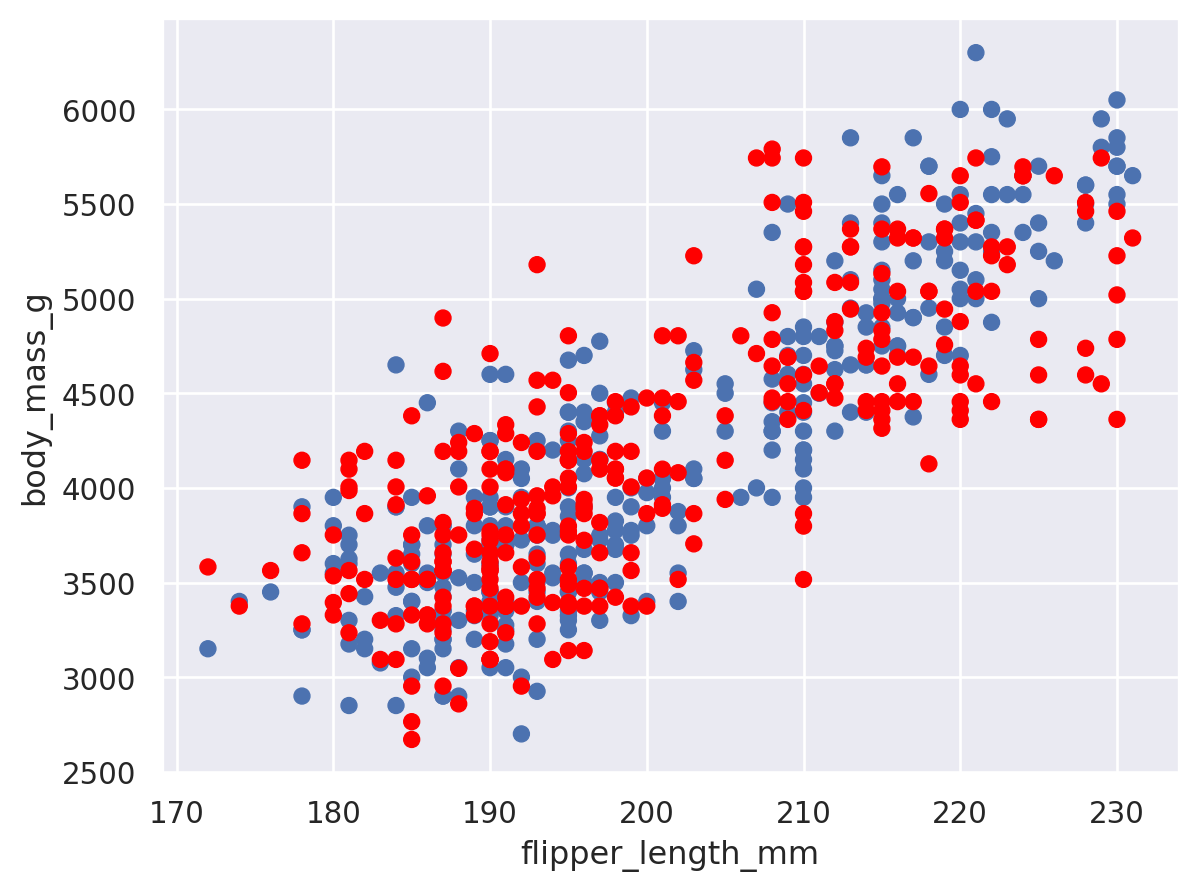

In [50]:
(
    so.Plot(penguins, x = "flipper_length_mm", y = "body_mass_g")
    .add(so.Dot())
    .add(so.Dot(color="red"), y = y_pred.flatten())
    # .add(so.Dot(color="red"), y = y_pred.flatten())
    # .add(so.Line(), so.PolyFit(order=1))
    # .add(so.Line(color="red"), so.PolyFit(order=1), y = y_pred.flatten())
)

Diferencia de peso entre macho y hembra para un mismo largo de aleta, es el beta 2 (347 g)

### Consultas

Al incluir una variable categorica como *sex*, hay que incluir el intercept? Cuando lo inclui, me genero dos coeficientes iguales y de signo contrario

En la utlima visualizacion, no supe como mostrar las predicciones

## Ejercicio 6

In [183]:
credit = pd.read_csv("../Notebooks/Datasets-20260209/credit.csv")
credit.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [184]:
# Separo variable predictora
y = credit.pop("Balance")
credit.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian
2,104.593,7075,514,4,71,11,Male,No,No,Asian
3,148.924,9504,681,3,36,11,Female,No,No,Asian
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian


LLevo las variables numericas al intervalo [0, 1]. Uso MinMaxScaler.

In [185]:
# Selecciono columnas numericas
numeric_cols = credit.select_dtypes(include="number")
numeric_cols.head()

,Income,Limit,Rating,Cards,Age,Education
0,14.891,3606,283,2,34,11
1,106.025,6645,483,3,82,15
2,104.593,7075,514,4,71,11
3,148.924,9504,681,3,36,11
4,55.882,4897,357,2,68,16


In [186]:
scaler = MinMaxScaler()
numeric_cols_scaled = scaler.fit_transform(numeric_cols)

len(numeric_cols_scaled), len(numeric_cols_scaled[0])

(400, 6)

In [187]:
numeric_cols_scaled_df = pd.DataFrame(
    numeric_cols_scaled,
    columns=numeric_cols.columns,
    index=numeric_cols.index
)
numeric_cols_scaled_df.head()

,Income,Limit,Rating,Cards,Age,Education
0,0.025737,0.210675,0.213723,0.125,0.146667,0.400000
1,0.542722,0.443406,0.438695,0.250,0.786667,0.666667
2,0.534598,0.476336,0.473566,0.375,0.640000,0.400000
3,0.786079,0.662353,0.661417,0.250,0.173333,0.400000
4,0.258271,0.309542,0.296963,0.125,0.600000,0.733333


In [194]:
RANDOM_STATE = 2

In [195]:
# Separo en entrenamiento / testeo
X_train, X_test, y_train, y_test = train_test_split(numeric_cols_scaled_df, y, test_size=0.2, random_state=RANDOM_STATE)

In [196]:
modelo_lineal = linear_model.LinearRegression()
modelo_lineal.fit(X_train, y_train)

y_pred = modelo_lineal.predict(X_test)

root_mean_squared_error(y_test, y_pred)

150.03257909795462

### Regresion Ridge

In [224]:
alphas = np.array([0.000001, 0.00001, 0.0001, 0.001, 0.005, 0.01, 0.02, 0.1, 0.5, 1, 10, 100, 1000])

Para cada alpha, hago validacion cruzada (KFold) en los datos de entrenamiento

In [225]:
cv = KFold(n_splits=5, random_state=RANDOM_STATE, shuffle=True)

coefs = []
for alpha in alphas:
    modelo_ridge = linear_model.Ridge(alpha=alpha, fit_intercept=True)
    
    rmse = []
    
    for train_idx, val_idx in cv.split(X_train):
        X_train_step, X_val_step, y_train_step, y_val_step = (
            X_train.iloc[train_idx], 
            X_train.iloc[val_idx], 
            y_train.iloc[train_idx], 
            y_train.iloc[val_idx]
        )
        modelo_ridge.fit(X_train_step, y_train_step)
    
        y_pred = modelo_ridge.predict(X_val_step)
        rmse.append(root_mean_squared_error(y_val_step, y_pred))
    
    print(f"Mean rmse for alpha={alpha}: {np.mean(rmse)}")

    coefs.append(modelo_ridge.coef_)

Mean rmse for alpha=1e-06: 166.34682252216092
Mean rmse for alpha=1e-05: 166.3466152658952
Mean rmse for alpha=0.0001: 166.34455501682493
Mean rmse for alpha=0.001: 166.325110547195
Mean rmse for alpha=0.005: 166.2580638806684
Mean rmse for alpha=0.01: 166.20183305525794
Mean rmse for alpha=0.02: 166.13399304226505
Mean rmse for alpha=0.1: 166.13190097818477
Mean rmse for alpha=0.5: 170.46571623414667
Mean rmse for alpha=1.0: 180.09385128028907
Mean rmse for alpha=10.0: 282.08709641655093
Mean rmse for alpha=100.0: 412.41406114131877
Mean rmse for alpha=1000.0: 456.3787240542959


El mejor rmse dio para $alpha = 0.1$

Entreno el modelo Ridge con este alpha en los datos de entrenamiento

In [226]:
modelo_ridge_mejor = linear_model.Ridge(alpha=0.1, fit_intercept=True)
modelo_ridge_mejor.fit(X_train, y_train)

y_pred = modelo_ridge_mejor.predict(X_test)

root_mean_squared_error(y_test, y_pred)

149.92918416243734

Esto esta dependiendo mucho del random_state que se use. A veces da mejor el LinearModel, otras veces da mejor el Ridge

En general da mejor Ridge con aplha 0.1

(np.float64(2818.382931264455), np.float64(3.548133892335753e-07))

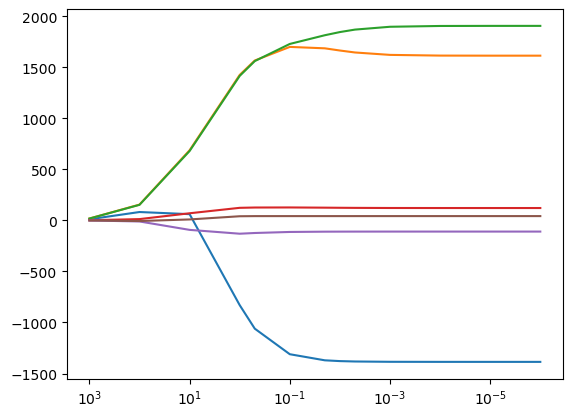

In [227]:
ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1])